In [10]:
import torch
import torch.nn as nn
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [11]:
# df = pd.read_csv('btc_max_ohlc_yfinance.csv')
df = pd.read_csv('btc_change_rate.csv')

df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'])

df.sort_values("date", axis=0, ascending=True, inplace=True)

# 篩選2021-07-01之後的資料
df = df[df['date'] >= '2021-07-01'].copy()

df = df.set_index('date')
# df.drop(['unix', 'symbol', 'tradecount'], axis=1, inplace=True)

In [12]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0)) # Shape: (1, max_len, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim=1, d_model=64, nhead=4, num_layers=2, output_dim=1):
        super().__init__()
        self.input_linear = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_linear = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.input_linear(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)

        out = x[:, -1, :]
        out = self.output_linear(out)
        return out

In [14]:
# rate

data = df.iloc[:, 0]

length = 30
windows = []
target = []

# Window Slide
for i in range(len(data) - length):
    x = data[i : i + length]
    y = data[i + length]
    windows.append(x)
    target.append(y)

windows = np.array(windows)
target = np.array(target).reshape(-1, 1)

sc = StandardScaler()
windows_scaled = sc.fit_transform(windows)
target_scaled = sc.fit_transform(target)

split_idx = int(len(windows_scaled) * 0.8)
X_train = windows_scaled[:split_idx]
y_train = target_scaled[:split_idx]
X_test = windows_scaled[split_idx:]
y_test = target_scaled[split_idx:]

# 轉成 Tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

/tmp/ipykernel_418/2003813796.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = data[i + length]


In [ ]:
# price

data = df.iloc[:, 3].values.reshape(-1, 1)

sc = MinMaxScaler()
data_scaled = sc.fit_transform(data)

length = 30
windows = []
target = []

# Window Slide
for i in range(len(data_scaled) - length):
    x = data_scaled[i : i + length]
    y = data_scaled[i + length]
    windows.append(x)
    target.append(y)

windows_scaled = np.array(windows)
target_scaled = np.array(target)

split_idx = int(len(windows_scaled) * 0.8)
X_train = windows_scaled[:split_idx]
y_train = target_scaled[:split_idx]
X_test = windows_scaled[split_idx:]
y_test = target_scaled[split_idx:]

# 轉成 Tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# training using GPU
model = TimeSeriesTransformer(input_dim=1, d_model=64, nhead=4, num_layers=2, output_dim=1).to(device)

# loss function
criterion = nn.MSELoss()

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 50 # 訓練輪數

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()

        batch_x = batch_x.unsqueeze(-1)

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')

Epoch [10/50], Loss: 1.101393
Epoch [20/50], Loss: 1.090934
Epoch [30/50], Loss: 1.089688
Epoch [40/50], Loss: 1.087394
Epoch [50/50], Loss: 1.090937


In [22]:
model.eval()
with torch.no_grad():
    if len(X_test_tensor.shape) == 2:
        X_test_tensor = X_test_tensor.unsqueeze(-1)

    X_test_tensor = X_test_tensor.to(device)

    predictions = model(X_test_tensor)

predictions = predictions.cpu().numpy()
actuals = y_test_tensor.numpy()

predictions_real = sc.inverse_transform(predictions)
actuals_real = sc.inverse_transform(actuals)

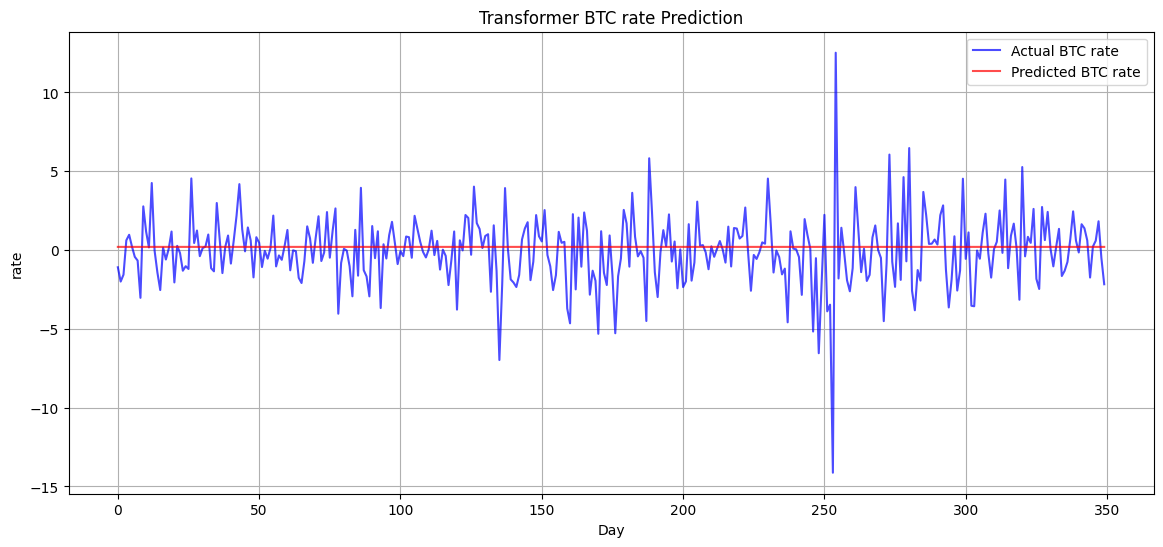

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(actuals_real, label='Actual BTC rate', color='blue', alpha=0.7)
plt.plot(predictions_real, label='Predicted BTC rate', color='red', alpha=0.7)

plt.title('Transformer BTC rate Prediction')
plt.xlabel('Day')
plt.ylabel('rate')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(actuals_real, label='Actual BTC Price', color='blue', alpha=0.7)
plt.plot(predictions_real, label='Predicted BTC Price', color='red', alpha=0.7)

plt.title('Transformer BTC Price Prediction')
plt.xlabel('Day')
plt.ylabel('USDT')
plt.legend()
plt.grid(True)
plt.show()